In [8]:
import matplotlib.pyplot as plt
import numpy as np
import ffs_defs as ffs


In [9]:
Q2_array = np.linspace(0,3,100)

In [15]:
# Compute axial from conformal variable parameterization
tc = 0.1753 # 9 * m_pi ^2, value lifted from paper
gA = -1.2723 
a_list_base = [2.30, -0.6, -3.8, 2.3] 

a_list = ffs.construct_a_list(a_list_base, gA, tc)
a_std_dv_list = [.13, 1.0, 2.5, 2.7]
correlation_matrix = [[1, 0.350, -0.678, 0.611],
                      [0.350, 1, -0.898, 0.367],
                      [-0.678, -0.898, 1, -0.685],
                      [0.611, 0.367, -0.685, 1]]

data_points = ffs.generate_samples(a_list_base, a_std_dv_list, correlation_matrix, 10000) # 
a_lists = np.array([ffs.construct_a_list(a_list_sample, gA, tc) for a_list_sample in data_points])
print(a_lists)
axial_ff_conf_array = np.array([-ffs.axial_conf(Q2, tc, a_list) for Q2 in Q2_array]) #the difference in plots comes from passing in the full a list from above

axial_ff_conf_error_array = np.array([ffs.axial_conf_err(Q2, tc, a_lists) for Q2 in Q2_array])

[[-0.71797386  2.43220653 -0.84910719 ... -0.08078717 -2.76419524
   1.28375485]
 [-0.78816547  2.34161362 -0.01048877 ...  1.44578242 -4.74393077
   1.90042517]
 [-0.62541262  2.13504828 -2.74057754 ... -3.34518816  4.62966041
  -1.56279641]
 ...
 [-0.8846014   2.58062819  1.12337734 ...  3.71132421 -5.53887066
   2.10440346]
 [-0.67092173  2.19699493 -1.8049846  ...  1.64206353 -2.00651081
   0.66577575]
 [-0.78844527  2.21891596 -0.43155061 ...  2.65615543 -3.02656837
   1.00097786]]


In [16]:
# Compute axial from dipole parameterization
mA = 1.014 
mA_std_dv = 0.014
axial_ff_dip_array = np.array([-ffs.axial_dipole(Q2, gA, mA) for Q2 in Q2_array])
axial_ff_dip_error_array = np.array([ffs.axial_dipole_err(Q2, gA, mA, mA_std_dv) for Q2 in Q2_array])

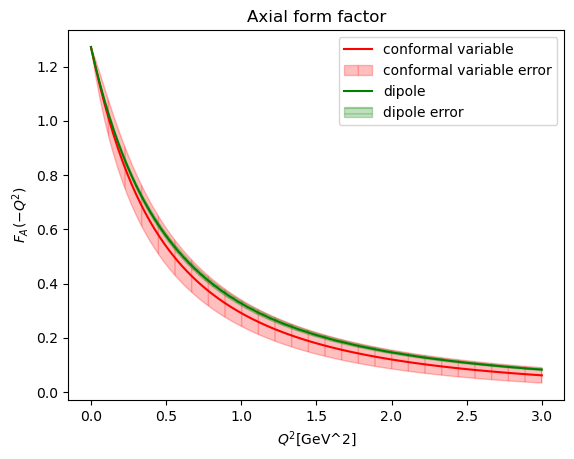

In [17]:
# Plot axial form factor
# -- conformal variable plot --
plt.plot(Q2_array, axial_ff_conf_array, label='conformal variable',color='red')
plt.fill_between(Q2_array, 
                 axial_ff_conf_array - axial_ff_conf_error_array, 
                 axial_ff_conf_array + axial_ff_conf_error_array,
                 label='conformal variable error', 
                 color='red', 
                 hatch='|',  # Vertical hatching
                 alpha=0.25)  # Semi-transparent fill

# -- dipole plot --
plt.plot(Q2_array, axial_ff_dip_array, label='dipole',color='green')
plt.fill_between(Q2_array, 
                 axial_ff_dip_array - axial_ff_dip_error_array, 
                 axial_ff_dip_array + axial_ff_dip_error_array,
                 label='dipole error', 
                 color='green', 
                 hatch='---',  # Vertical hatching
                 alpha=0.25)  # Semi-transparent fill
plt.title('Axial form factor')
plt.ylabel(r'$F_A(-Q^2)$')
plt.xlabel('$Q^2$[GeV^2]')
plt.legend()